# Pharmaceutical Sales Analysis

## 1. Introduction

This project explores pharmaceutical sales data recorded between January 2014 and October 2019. The dataset contains daily sales quantities for eight different drug categories, along with information about the date and time of each record. 
The aim of this analysis is to identify patterns and trends in pharmaceutical sales, including differences between drug categories, changes in sales over time and seasonal pattern. Python, Pandas and Matplotlib are use to clean, analyse and visualise the data.

## 2. Dataset Overview and Cleaning

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data/salesdaily.csv")

In [4]:
df.head()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [5]:
df.shape

(2106, 13)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         2106 non-null   str    
 1   M01AB         2106 non-null   float64
 2   M01AE         2106 non-null   float64
 3   N02BA         2106 non-null   float64
 4   N02BE         2106 non-null   float64
 5   N05B          2106 non-null   float64
 6   N05C          2106 non-null   float64
 7   R03           2106 non-null   float64
 8   R06           2106 non-null   float64
 9   Year          2106 non-null   int64  
 10  Month         2106 non-null   int64  
 11  Hour          2106 non-null   int64  
 12  Weekday Name  2106 non-null   str    
dtypes: float64(8), int64(3), str(2)
memory usage: 214.0 KB


In [7]:
df["datum"].head(10)

0     1/2/2014
1     1/3/2014
2     1/4/2014
3     1/5/2014
4     1/6/2014
5     1/7/2014
6     1/8/2014
7     1/9/2014
8    1/10/2014
9    1/11/2014
Name: datum, dtype: str

In [8]:
df["datum"] = pd.to_datetime(df["datum"])

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   datum         2106 non-null   datetime64[us]
 1   M01AB         2106 non-null   float64       
 2   M01AE         2106 non-null   float64       
 3   N02BA         2106 non-null   float64       
 4   N02BE         2106 non-null   float64       
 5   N05B          2106 non-null   float64       
 6   N05C          2106 non-null   float64       
 7   R03           2106 non-null   float64       
 8   R06           2106 non-null   float64       
 9   Year          2106 non-null   int64         
 10  Month         2106 non-null   int64         
 11  Hour          2106 non-null   int64         
 12  Weekday Name  2106 non-null   str           
dtypes: datetime64[us](1), float64(8), int64(3), str(1)
memory usage: 214.0 KB


In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.select_dtypes(include="number").min()

M01AB       0.0
M01AE       0.0
N02BA       0.0
N02BE       0.0
N05B        0.0
N05C        0.0
R03         0.0
R06         0.0
Year     2014.0
Month       1.0
Hour      190.0
dtype: float64

In [12]:
df["datum"].min(), df["datum"].max()

(Timestamp('2014-01-02 00:00:00'), Timestamp('2019-10-08 00:00:00'))

In [13]:
df["datum"].diff().value_counts()

datum
1 days    2105
Name: count, dtype: int64

In [14]:
df.columns

Index(['datum', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03',
       'R06', 'Year', 'Month', 'Hour', 'Weekday Name'],
      dtype='str')

In [15]:
df.describe()

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour
count,2106,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000,2106.000000
mean,2016-11-19 12:00:00,5.033683,3.895830,3.880441,29.917095,8.853627,0.593522,5.512262,2.900198,2016.401235,6.344255,275.945869
min,2014-01-02 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2014.000000,1.000000,190.000000
25%,2015-06-12 06:00:00,3.000000,2.340000,2.000000,19.000000,5.000000,0.000000,1.000000,1.000000,2015.000000,3.000000,276.000000
50%,2016-11-19 12:00:00,4.990000,3.670000,3.500000,26.900000,8.000000,0.000000,4.000000,2.000000,2016.000000,6.000000,276.000000
75%,2018-04-29 18:00:00,6.670000,5.138000,5.200000,38.300000,12.000000,1.000000,8.000000,4.000000,2018.000000,9.000000,276.000000
max,2019-10-08 00:00:00,17.340000,14.463000,16.000000,161.000000,54.833333,9.000000,45.000000,15.000000,2019.000000,12.000000,276.000000
std,NaN,2.737579,2.133337,2.384010,15.590966,5.605605,1.092988,6.428736,2.415816,1.665060,3.386954,1.970547


## 3. Exploratory Analysis

### 3.1 Overall Sales by Drug Category

In [99]:
total_sales = df.iloc[:, 1:9].sum()

In [100]:
total_sales.sort_values(ascending=False)

N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333
dtype: float64

Text(0, 0.5, 'Total Sales')

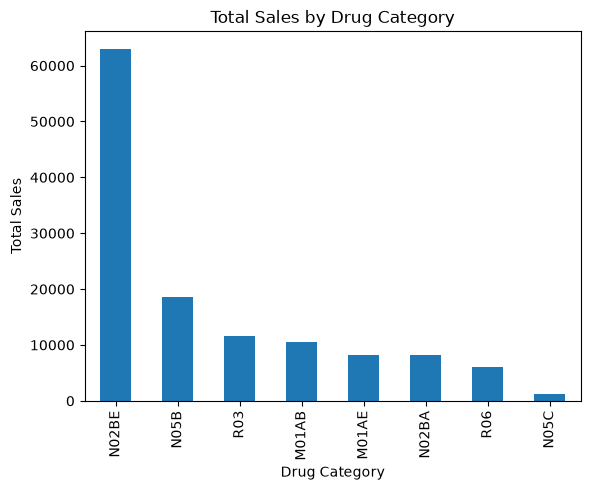

In [101]:
total_sales.sort_values(ascending=False).plot(kind="bar")
plt.title("Total Sales by Drug Category")
plt.xlabel("Drug Category")
plt.ylabel("Total Sales")

In [102]:
print(f"Drug Category with Highest Total Sales: {total_sales.idxmax()} with {total_sales.max()} sales")

Drug Category with Highest Total Sales: N02BE with 63005.40270834 sales


### 3.2 Annual Sales Trends

In [ ]:
annual_sales = df.groupby("Year")[df.columns[1:9]].sum()
annual_total_sales = annual_sales.sum(axis=1)

Text(0, 0.5, 'Total Sales')

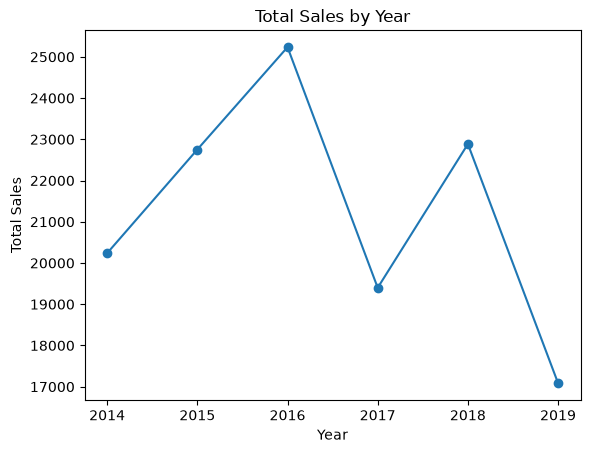

In [162]:
annual_total_sales.plot(kind="line", marker="o")
plt.title("Total Sales by Year")
plt.xlabel("Year")
plt.ylabel("Total Sales")

Sales increased between 2014 and 2016, when they reached their highest level. There was then a drop in 2017 before sales increased again in 2018. Sales then significantly dropped back in 2019, although this should be interpreted with caution as the dataset only covers part of the year.

### 3.3 Drug Category Trends Over Time

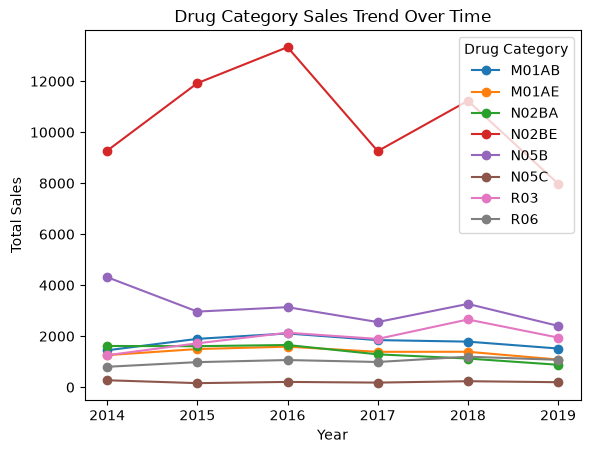

In [193]:
annual_sales.plot(kind="line", marker="o")
plt.title("Drug Category Sales Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.legend(title="Drug Category")

N02BE had the highest sales throughout the period, while N05B consistently had the second-highest sales. N05C had the lowest sales but remained relatively stable. N02BE also showed the most noticeable changes over time, with a significant decline between 2016 and 2017 followed by an increase in 2018.

### 3.4 Seasonality

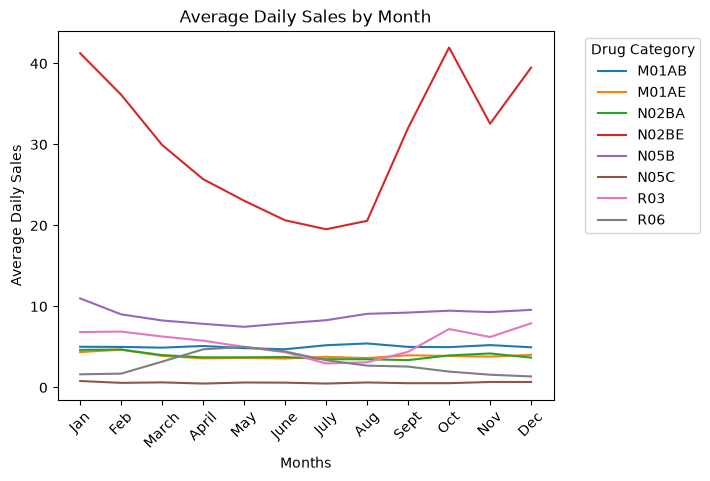

In [220]:
monthly_sales = df.groupby("Month")[df.columns[1:9]].mean()
monthly_sales.plot()
plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "March", "April", "May", "June", "July", "Aug", "Sept", "Oct", "Nov", "Dec"],
    rotation=45
)

plt.title("Average Daily Sales by Month")
plt.xlabel("Months")
plt.ylabel("Average Daily Sales")
plt.legend(title="Drug Category", bbox_to_anchor=(1.05, 1), loc="upper left")

N02BE and R03 showed the clearest seasonal variation, with sales generally declining towards the summer months before increasing again during autumn. In contrast, R06 behaves differently from the others as it increases from February and reaches relatively stable levels around April to June before declining. 

### 3.5 Sales Composition

Text(0.5, 1.0, 'Share of Total Sales by Drug Category')

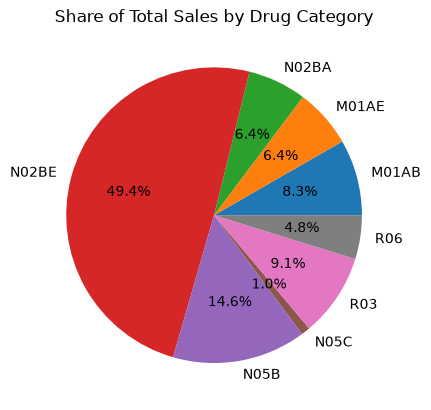

In [225]:
sales_percentage = (total_sales / total_sales.sum()) * 100
sales_percentage.plot(kind="pie", autopct="%1.1f%%")
plt.title("Share of Total Sales by Drug Category")

N02BE accounted for 49.4% of total sales, making up almost half of all recorded sales. N05B had the second-largest share at 14.6%, while N05C accounted for the smallest share at 1%. The remaining categories each contributed between 4.8% and 9.1% of total sales

### 3.6 Investigating Unusually High Sales Days

In [226]:
daily_total_sales = df[df.columns[1:9]].sum(axis=1)
daily_total_sales.describe()

count    2106.000000
mean       60.586659
std        21.561684
min         0.000000
25%        46.446750
50%        58.466500
75%        72.814250
max       198.950000
dtype: float64

In [227]:
top_days = df.loc[daily_total_sales.nlargest(10).index, ["datum"]]
top_days["Total Sales"] = daily_total_sales.nlargest(10).values
top_days

,datum,Total Sales
1093,2016-12-30,198.950000
1844,2019-01-20,162.283000
1094,2016-12-31,151.239000
1857,2019-02-02,150.508000
1851,2019-01-27,145.365000
1850,2019-01-26,141.659000
1031,2016-10-29,141.470000
1013,2016-10-11,138.819333
1004,2016-10-02,138.256000
725,2015-12-28,127.799000


In [228]:
top_indices = daily_total_sales.nlargest(10).index
top_days_details = df.loc[
    top_indices,
    ["datum"] + list(df.columns[1:9])
]
top_days_details

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
1093,2016-12-30,5.66,8.990,7.30,161.000,13.000000,0.0,3.0,0.0
1844,2019-01-20,11.67,14.463,2.10,93.050,6.000000,0.0,34.0,1.0
1094,2016-12-31,8.33,7.759,7.45,108.700,7.000000,0.0,12.0,0.0
1857,2019-02-02,13.34,12.706,6.20,64.262,8.000000,1.0,45.0,0.0
1851,2019-01-27,10.52,11.745,2.00,100.100,12.000000,1.0,6.0,2.0
1850,2019-01-26,7.00,8.459,2.40,97.800,11.000000,1.0,13.0,1.0
1031,2016-10-29,15.33,4.540,6.10,78.500,23.000000,0.0,9.0,5.0
1013,2016-10-11,7.33,2.406,11.65,52.600,54.833333,1.0,8.0,1.0
1004,2016-10-02,17.00,4.056,9.70,80.500,6.000000,0.0,18.0,3.0
725,2015-12-28,4.00,5.099,9.20,61.500,18.000000,3.0,26.0,1.0


In [229]:
top_days_average = top_days_details.iloc[:, 1:].mean().sort_values(ascending=False)
top_days_average

N02BE    89.801200
R03      17.400000
N05B     15.883333
M01AB    10.018000
M01AE     8.022300
N02BA     6.410000
R06       1.400000
N05C      0.700000
dtype: float64

In [231]:
overall_average = df.iloc[:, 1:9].mean()

comparison = pd.DataFrame({
    "Overall Average": overall_average,
    "Top 10 Days Average": top_days_average
})

comparison["Increase"] = comparison["Top 10 Days Average"] - comparison["Overall Average"]

comparison

,Overall Average,Top 10 Days Average,Increase
M01AB,5.033683,10.018000,4.984317
M01AE,3.895830,8.022300,4.126470
N02BA,3.880441,6.410000,2.529559
N02BE,29.917095,89.801200,59.884105
N05B,8.853627,15.883333,7.029707
N05C,0.593522,0.700000,0.106478
R03,5.512262,17.400000,11.887738
R06,2.900198,1.400000,-1.500198


To investigate unusually high sales days, I identified the 10 days with the highest total sales across all drug categories. I then compared the average sales for each category on these days with its overall daily average.

N02BE had the largest increase, averaging 89.90 on the top 10 days compared with its overall average of 29.92. R03 also showed a substantial increase from 5.51 to 17.40. R06 was the only category with a lower average on these days. These results suggest that unusually high total sales were primarily associated with increased sales of N02BE, with R03 also contributing. However, this analysis does not establish what caused these increases.

## 4. Conclusion 

This project analysed pharmaceutical sales data from January 2014 to October 2019 to explore differences between drug categories, trends over time and seasonal patterns.

The analysis found that N02BE consistently had the highest sales, accounting for almost half of total sales. Overall sales increased between 2014 and 2016, declined in 2017 and rose again in 2018. Seasonal patterns also varied between categories, with the majority of drugs showing decreasing sales over the summer period and increasing in the colder months, except R06, which showed the opposite pattern. Additionally, the investigation of the 10 highest-sales days found that these were largely driven by increased N02BE sales.

Although the analysis identified several patterns, it does not establish the causes behind them. The incomplete 2019 data also limits comparisons with previous years.